# Completion % NN

MLP with learned thrower embedding vs XGBoost baseline (AUC 0.8169).

Architecture: 8 continuous features + 16-dim thrower embedding → [128, 64, 32] → sigmoid

In [8]:
import psycopg2
from psycopg2.extras import RealDictCursor
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, brier_score_loss
import joblib, os, matplotlib.pyplot as plt

In [9]:
DB_CONFIG = {
    'dbname': 'ufa_analytics',
    'user': os.getenv('DB_USER', 'postgres'),
    'password': '',
    'host': 'localhost',
    'port': 5432
}

conn = psycopg2.connect(**DB_CONFIG, cursor_factory=RealDictCursor)
cur = conn.cursor()

cur.execute("""
    SELECT
        e.thrower,
        CASE WHEN e.team = g.away_team_id THEN -e.thrower_x   ELSE e.thrower_x   END AS from_x,
        CASE WHEN e.team = g.away_team_id THEN 120-e.thrower_y ELSE e.thrower_y   END AS from_y,
        CASE WHEN e.event_type IN (18,19)
             THEN (CASE WHEN e.team = g.away_team_id THEN -e.receiver_x   ELSE e.receiver_x   END)
             ELSE (CASE WHEN e.team = g.away_team_id THEN -e.turnover_x   ELSE e.turnover_x   END)
        END AS to_x,
        CASE WHEN e.event_type IN (18,19)
             THEN (CASE WHEN e.team = g.away_team_id THEN 120-e.receiver_y ELSE e.receiver_y   END)
             ELSE (CASE WHEN e.team = g.away_team_id THEN 120-e.turnover_y ELSE e.turnover_y   END)
        END AS to_y,
        CASE WHEN e.event_type IN (18,19) THEN 1 ELSE 0 END AS completed
    FROM events e JOIN games g ON e.game_id = g.game_id
    WHERE e.event_type IN (18,19,20,22) AND e.thrower IS NOT NULL AND e.thrower_x IS NOT NULL
      AND ((e.event_type IN (18,19) AND e.receiver_x IS NOT NULL)
        OR (e.event_type IN (20,22) AND e.turnover_x IS NOT NULL))
""")

rows = cur.fetchall()
cur.close()
conn.close()

df = pd.DataFrame(rows)
print(f'Rows: {len(df):,} | Completion rate: {df["completed"].mean():.3f} | Throwers: {df["thrower"].nunique()}')

Rows: 444,551 | Completion rate: 0.941 | Throwers: 1973


In [10]:
df['dy']    = df['to_y'] - df['from_y']
df['dx']    = df['to_x'] - df['from_x']
df['dist']  = np.sqrt(df['dx']**2 + df['dy']**2)
df['angle'] = np.arctan2(df['dy'], df['dx'])

le = LabelEncoder()
df['thrower_idx'] = le.fit_transform(df['thrower'])

CONT_COLS = ['from_x', 'from_y', 'to_x', 'to_y', 'dist', 'dy', 'dx', 'angle']

X_cont   = df[CONT_COLS].values.astype(np.float32)
X_throw  = df['thrower_idx'].values.astype(np.int64)
y        = df['completed'].values.astype(np.float32)

(
    X_cont_tr, X_cont_te,
    X_throw_tr, X_throw_te,
    y_tr, y_te
) = train_test_split(X_cont, X_throw, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_cont_tr = scaler.fit_transform(X_cont_tr).astype(np.float32)
X_cont_te = scaler.transform(X_cont_te).astype(np.float32)

print(f'Train: {len(y_tr):,} | Test: {len(y_te):,}')
print(f'Continuous features: {len(CONT_COLS)} | Throwers: {len(le.classes_)}')

Train: 355,640 | Test: 88,911
Continuous features: 8 | Throwers: 1973


In [11]:
class ThrowDataset(Dataset):
    def __init__(self, X_cont, X_throw, y):
        self.X_cont  = torch.FloatTensor(X_cont)
        self.X_throw = torch.LongTensor(X_throw)
        self.y       = torch.FloatTensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X_cont[i], self.X_throw[i], self.y[i]


class CompletionNet(nn.Module):
    def __init__(self, n_throwers, embed_dim=16, hidden=(128, 64, 32), dropout=0.3):
        super().__init__()
        self.embed = nn.Embedding(n_throwers, embed_dim)
        in_dim = 8 + embed_dim  # 8 continuous + embedding
        layers = []
        for h in hidden:
            layers += [nn.Linear(in_dim, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
            dropout = max(dropout - 0.1, 0.1)
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x_cont, x_throw):
        emb = self.embed(x_throw)
        x   = torch.cat([x_cont, emb], dim=1)
        return self.net(x).squeeze(1)


DEVICE     = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
EMBED_DIM  = 16
BATCH      = 1024
EPOCHS     = 30
LR         = 1e-3

print(f'Device: {DEVICE}')

train_ds = ThrowDataset(X_cont_tr, X_throw_tr, y_tr)
test_ds  = ThrowDataset(X_cont_te, X_throw_te, y_te)
train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=0)
test_dl  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=0)

model    = CompletionNet(n_throwers=len(le.classes_), embed_dim=EMBED_DIM).to(DEVICE)
# Up-weight negatives (turnovers are rare, ~5.9%)
criterion = nn.BCEWithLogitsLoss()
optimizer  = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

total_params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {total_params:,}')

Device: mps
Parameters: 45,585


In [12]:
best_auc = 0.0
best_state = None
history = []

for epoch in range(1, EPOCHS + 1):
    # --- train ---
    model.train()
    train_loss = 0.0
    for x_cont, x_throw, y_batch in train_dl:
        x_cont, x_throw, y_batch = x_cont.to(DEVICE), x_throw.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = model(x_cont, x_throw)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(y_batch)
    train_loss /= len(train_ds)

    # --- eval ---
    model.eval()
    all_logits, all_y = [], []
    with torch.no_grad():
        for x_cont, x_throw, y_batch in test_dl:
            x_cont, x_throw = x_cont.to(DEVICE), x_throw.to(DEVICE)
            all_logits.append(model(x_cont, x_throw).cpu())
            all_y.append(y_batch)
    all_logits = torch.cat(all_logits).numpy()
    all_y      = torch.cat(all_y).numpy()
    probs      = torch.sigmoid(torch.tensor(all_logits)).numpy()

    auc   = roc_auc_score(all_y, probs)
    brier = brier_score_loss(all_y, probs)
    history.append({'epoch': epoch, 'train_loss': train_loss, 'auc': auc, 'brier': brier})

    if auc > best_auc:
        best_auc   = auc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    scheduler.step()

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:2d} | loss={train_loss:.4f} | AUC={auc:.4f} | Brier={brier:.4f}')

print(f'\nBest AUC: {best_auc:.4f}  (XGBoost baseline: 0.8169)')

Epoch  1 | loss=0.3251 | AUC=0.7854 | Brier=0.0485
Epoch  5 | loss=0.1829 | AUC=0.8134 | Brier=0.0474
Epoch 10 | loss=0.1792 | AUC=0.8224 | Brier=0.0471
Epoch 15 | loss=0.1759 | AUC=0.8227 | Brier=0.0470
Epoch 20 | loss=0.1727 | AUC=0.8191 | Brier=0.0471
Epoch 25 | loss=0.1700 | AUC=0.8151 | Brier=0.0472
Epoch 30 | loss=0.1694 | AUC=0.8147 | Brier=0.0472

Best AUC: 0.8227  (XGBoost baseline: 0.8169)


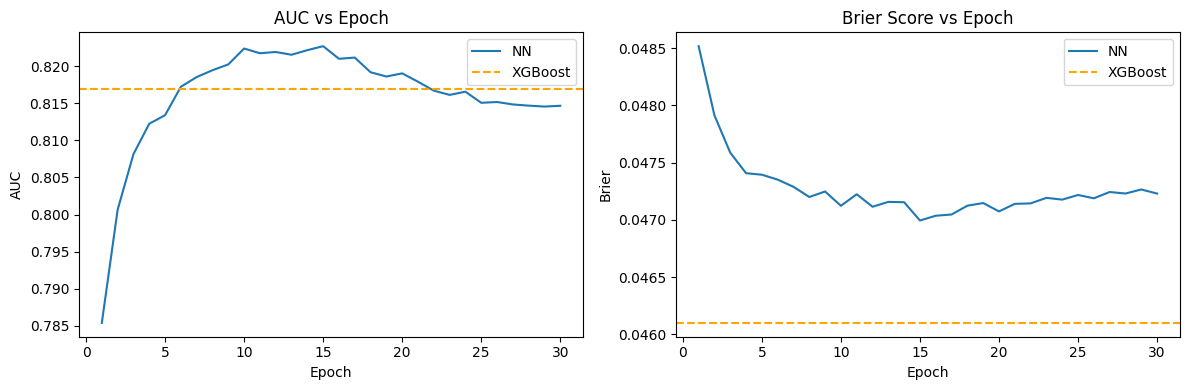

In [13]:
hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_df['epoch'], hist_df['auc'], label='NN')
axes[0].axhline(0.8169, color='orange', linestyle='--', label='XGBoost')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('AUC'); axes[0].set_title('AUC vs Epoch')
axes[0].legend()
axes[1].plot(hist_df['epoch'], hist_df['brier'], label='NN')
axes[1].axhline(0.0461, color='orange', linestyle='--', label='XGBoost')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Brier'); axes[1].set_title('Brier Score vs Epoch')
axes[1].legend()
plt.tight_layout()
plt.show()

In [14]:
# Restore best checkpoint and save
model.load_state_dict(best_state)
model.eval()

# Final eval
all_logits, all_y = [], []
with torch.no_grad():
    for x_cont, x_throw, y_batch in test_dl:
        x_cont, x_throw = x_cont.to(DEVICE), x_throw.to(DEVICE)
        all_logits.append(model(x_cont, x_throw).cpu())
        all_y.append(y_batch)
all_logits = torch.cat(all_logits).numpy()
all_y      = torch.cat(all_y).numpy()
probs      = torch.sigmoid(torch.tensor(all_logits)).numpy()

final_auc   = roc_auc_score(all_y, probs)
final_brier = brier_score_loss(all_y, probs)
print(f'NN   → AUC: {final_auc:.4f} | Brier: {final_brier:.4f}')
print(f'XGB  → AUC: 0.8169        | Brier: 0.0461')

os.makedirs('models', exist_ok=True)
joblib.dump({
    'model_type': 'nn',
    'model_state': best_state,
    'model_config': {
        'n_throwers': len(le.classes_),
        'embed_dim': EMBED_DIM,
        'hidden': (128, 64, 32),
    },
    'encoder': le,
    'scaler': scaler,
    'feature_names': CONT_COLS,
    'metrics': {'auc': float(final_auc), 'brier': float(final_brier)},
}, 'models/completion_nn.pkl')

size_kb = os.path.getsize('models/completion_nn.pkl') / 1024
print(f'Saved models/completion_nn.pkl ({size_kb:.0f} KB)')

NN   → AUC: 0.8227 | Brier: 0.0470
XGB  → AUC: 0.8169        | Brier: 0.0461
Saved models/completion_nn.pkl (208 KB)
